# QAOA Example (MaxCut)

这里展示如何使用 `cqlib-algorithm` 中的 QAOA 求解 MaxCut 问题。

In [15]:
from cqlib_algorithm.problems.maxcut import MaxCut
from cqlib_algorithm.mappings.convert import maxcut_to_qubo, qubo_to_ising
from cqlib_algorithm.visualization.maxcut_plot import plot_maxcut
from cqlib_algorithm.execution import LocalRunner
from cqlib_algorithm.algorithms.qaoa import QAOASolver, QAOAConfig
from cqlib_algorithm.optimizers.options import OptimizerOptions

print("Imports ready")

Imports ready


## 1. 定义 MaxCut 实例

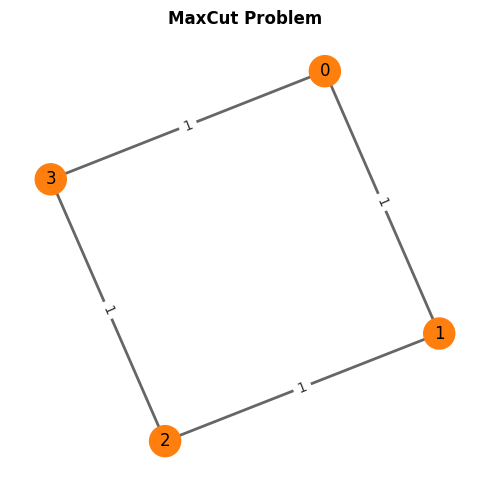

In [16]:
weights = {(0, 1): 1, (1, 2): 1, (2, 3): 1, (3, 0): 1}
mc = MaxCut(n=4, weights=weights)
plot_maxcut(n=mc.n, weights=mc.weights, partition={}, title="MaxCut Problem")

## 2. MaxCut → QUBO

In [17]:
qubo = maxcut_to_qubo(mc)
print(qubo)

========== [ QUBO ] ==========
Maximize: - 2*x_0*x_1 - 2*x_0*x_3 - 2*x_1*x_2 - 2*x_2*x_3 + 2*x_0 + 2*x_1 + 2*x_2 + 2*x_3



## 3. QUBO → Ising

In [18]:
ising = qubo_to_ising(qubo)
print(ising)

========== [ Ising Hamiltonian ] ==========
Paulis = ['IIZZ', 'ZIIZ', 'IZZI', 'ZZII'],
coeffs = [0.500, 0.500, 0.500, 0.500]
offset = -2.000



## 4. 运行 QAOA（LocalRunner）

[iter=  1] f=0.834 theta=[0.834, 0.766, 0.834, 0.234, 0.166, 0.166]
[iter=  2] f=-0.464 theta=[1.659, -0.059, 1.659, -0.591, -0.659, 0.991]
[iter=  3] f=-0.892 theta=[2.360, 0.641, 2.360, -1.292, 0.041, 0.291]
[iter=  4] f=-0.996 theta=[2.110, 0.392, 2.610, -1.542, 0.291, 0.041]
[iter=  5] f=-0.168 theta=[1.946, 0.227, 2.774, -1.377, 0.455, 0.205]
[iter=  6] f=-0.274 theta=[1.861, 0.142, 2.859, -1.463, 0.541, 0.120]
[iter=  7] f=-0.024 theta=[2.200, -0.197, 2.520, -1.802, 0.201, -0.219]
[iter=  8] f=-0.120 theta=[2.082, -0.315, 2.402, -1.684, 0.084, -0.101]
[iter=  9] f=-0.594 theta=[2.382, -0.614, 2.103, -1.384, 0.383, -0.401]
[iter= 10] f=-0.482 theta=[2.153, -0.843, 1.874, -1.613, 0.155, -0.629]
[iter= 11] f=-0.520 theta=[2.132, -0.864, 1.895, -1.634, 0.176, -0.608]
[iter= 12] f=-0.564 theta=[2.005, -0.737, 2.023, -1.761, 0.303, -0.481]
[iter= 13] f=-0.554 theta=[2.338, -0.403, 2.356, -1.428, -0.030, -0.814]
[iter= 14] f=-0.008 theta=[1.976, -0.766, 2.719, -1.065, 0.333, -0.451]
[it

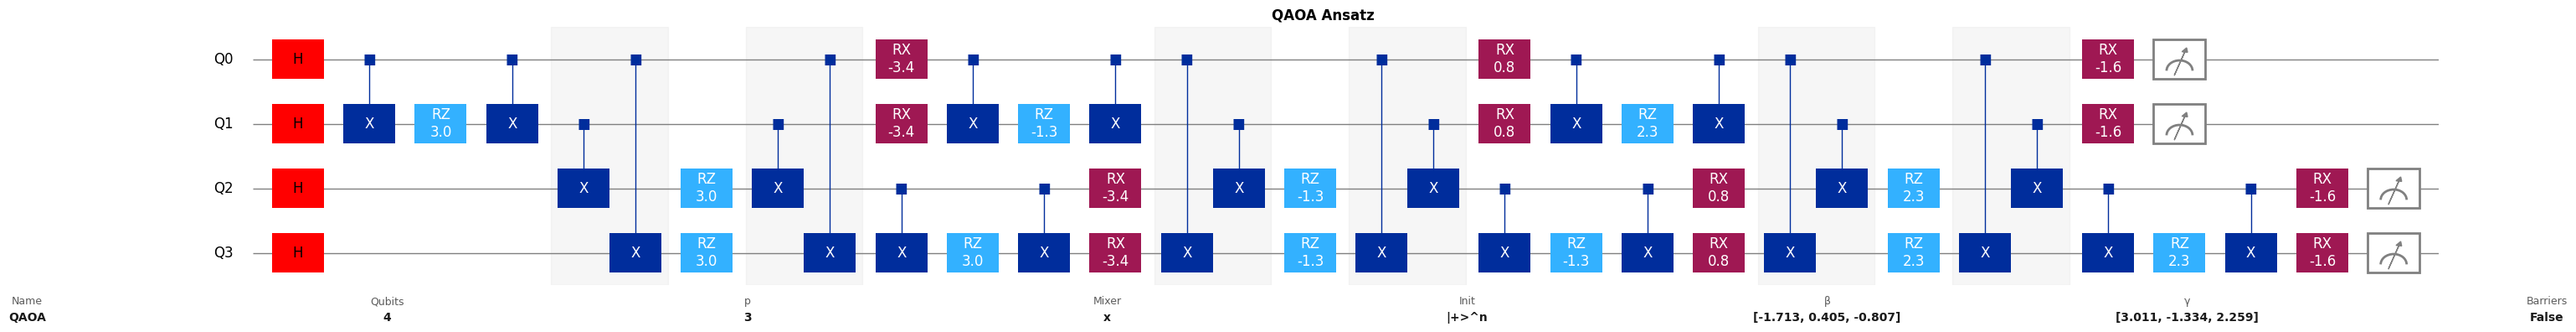

In [19]:
opt_cfg = OptimizerOptions(name="spsa", options={"maxiter": 1000})
solver = QAOASolver(
    ising, runner=LocalRunner(), qaoa_cfg=QAOAConfig(reps=3, mixer="x"), opt_cfg=opt_cfg
)
res = solver.run()

## 5. 可视化：运行结果

In [20]:
res.print_result()


========== [ Experiment Information ] ==========
Task ID  : 20251030161737
Shots  : 1000

========== [ Optimize Configs ] ==========
runner      : LocalRunner
qaoa_cfg    : {'reps': 3, 'mixer': 'x', 'shots': 1000, 'name': 'QAOA', 'wrap_angles': True, 'need_transpile': None, 'verbose': True}
opt_cfg    : {'name': 'spsa', 'options': {'maxiter': 1000}}

========== [ Measurement Results ] ==========
probability : {'0101': 0.513, '1010': 0.487}


## 6. 可视化：迭代曲线与概率分布

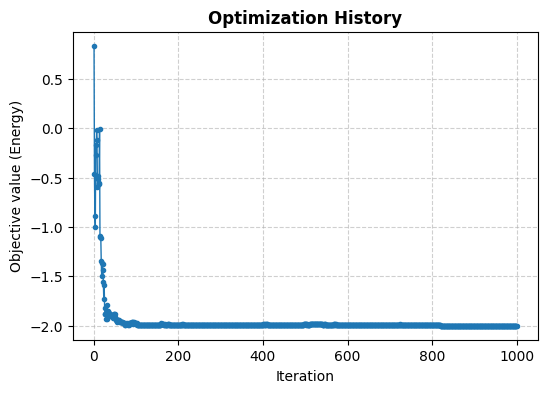

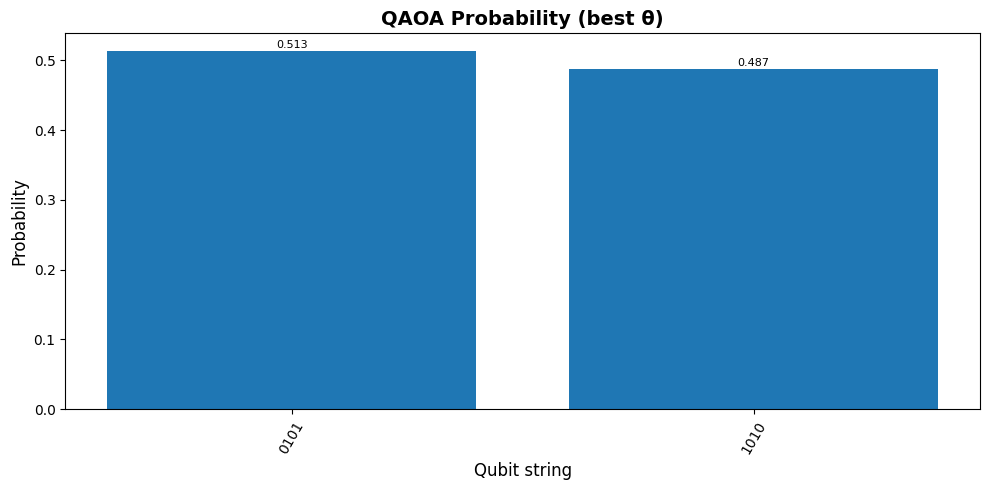

In [21]:
res.plot_history(title="Optimization History")
res.plot_probability(title="QAOA Probability (best θ)", topk=20)

## 7. 可视化：最优 MaxCut 解


========== [ Optimization Results ] ==========
Best gammas : [3.011, -1.334, 2.259]
Best betas  : [-1.713, 0.405, -0.807]
Best energy : -2.000
Best Qubit string:  0101
Best solution: [1, 3]
Max-Cut value: 4.000


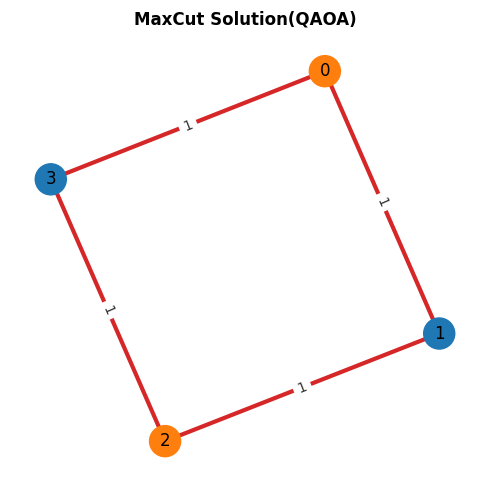

[1, 3]

In [22]:
res.plot_maxcut_solution(n=mc.n, weights=mc.weights, title="MaxCut Solution(QAOA)")

### 可选：对接中电信“天衍”量子计算云平台后端
将 `LocalRunner()` 替换为 `TianYanRunner()`：
```python
from cqlib_algorithm.execution import TianYanRunner
runner = TianYanRunner(login_key='YOUR_KEY', machine='tianyan_sw')
```
